# Analysis of results

### Setup

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Setup working directory
from pathlib import Path
import os

def find_root_dir(marker='tfg'):
    p = Path.cwd()
    for candidate in [p] + list(p.parents):
        if candidate.name == marker:
            return candidate.resolve()
        if (candidate / marker).is_dir():
            return (candidate / marker).resolve()
    raise FileNotFoundError(f"Could not find '{marker}' folder in {Path.cwd()} or its parents.")

os.chdir(find_root_dir('tfg'))

In [3]:
# Libraries for data manipulation and visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set Searborn style (background color, grid, axes, etc.) 
sns.set_style("whitegrid")

# Default values and styling for all plots
plt.rcParams.update({
    "figure.autolayout": True,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": False
})

## Configuration
- DataFrame containing the results of **15 experiments** (5 models x 3 feature configurations)
- Expected columns: `Model`,`Feature Set`,`Features Count`,`Train Time`,`Train Accuracy`,`Train F1`,`BENIGN`, `DDoS`, `FP`, `FN`, `TP`, `TN`, `FP Rate`, `Accuracy`, `F1`, `Feature Names`

In [4]:
RESULTS = "results/results_stage_II.json"
df = pd.read_json(RESULTS, orient="split")

In [5]:
feature_order = [
    "filtered",
    "log",
    "correlation_098"
]

df["Feature Set"] = pd.Categorical(
    df["Feature Set"],
    categories=feature_order,
    ordered=True
)

df = df.sort_values(
    ["Model", "Feature Set"]
).reset_index(drop=True)

display(df)

,Model,Feature Set,Features Count,Train Time,Train Accuracy,Train F1,BENIGN,DDoS,FP,FN,TP,TN,FP Rate,Accuracy,F1,Features Names
0,Decision Tree,filtered,59,2.748,0.999941,0.999941,9760,12801,9,9,12792,9751,0.000922,0.999202,0.999202,"[Flow Duration, Total Fwd Packets, Total Backw..."
1,Decision Tree,log,59,2.714,0.999941,0.999941,9760,12801,8,9,12792,9752,0.000820,0.999246,0.999246,"[Flow Duration, Total Fwd Packets, Total Backw..."
2,Decision Tree,correlation_098,43,2.147,0.999941,0.999941,9760,12801,10,9,12792,9750,0.001025,0.999158,0.999158,"[Flow Duration, Total Fwd Packets, Total Backw..."
3,Logistic Regression,filtered,59,21.358,0.959476,0.959270,9760,12801,811,116,12685,8949,0.083094,0.958911,0.958696,"[Flow Duration, Total Fwd Packets, Total Backw..."
4,Logistic Regression,log,59,20.611,0.973700,0.973592,9760,12801,586,12,12789,9174,0.060041,0.973494,0.973383,"[Flow Duration, Total Fwd Packets, Total Backw..."
5,Logistic Regression,correlation_098,43,20.229,0.955980,0.955802,9760,12801,769,215,12586,8991,0.078791,0.956385,0.956210,"[Flow Duration, Total Fwd Packets, Total Backw..."
6,MLP,filtered,59,38.152,0.972375,0.972256,9760,12801,576,17,12784,9184,0.059016,0.973716,0.973609,"[Flow Duration, Total Fwd Packets, Total Backw..."
7,MLP,log,59,76.496,0.981979,0.981953,9760,12801,300,84,12717,9460,0.030738,0.982979,0.982955,"[Flow Duration, Total Fwd Packets, Total Backw..."
8,MLP,correlation_098,43,40.355,0.979162,0.979099,9760,12801,437,18,12783,9323,0.044775,0.979832,0.979774,"[Flow Duration, Total Fwd Packets, Total Backw..."
9,SVC,filtered,59,4785.073,0.937171,0.937027,9760,12801,849,563,12238,8911,0.086988,0.937414,0.937295,"[Flow Duration, Total Fwd Packets, Total Backw..."


**Attention!**: Although SVC was included in Stage I as a baseline model, its computational cost became prohibitive when moving to the complete 225k-instance dataset. Training a single SVC configuration required more than 30 minutes, making the evaluation of multiple feature representations and preprocessing configurations impractical. SVC was **excluded** from the comparison on the complete dataset.

## F1-Score Analysis
**Objective**: to have a overall overview and show which configurations stand out and which show degradation.

---

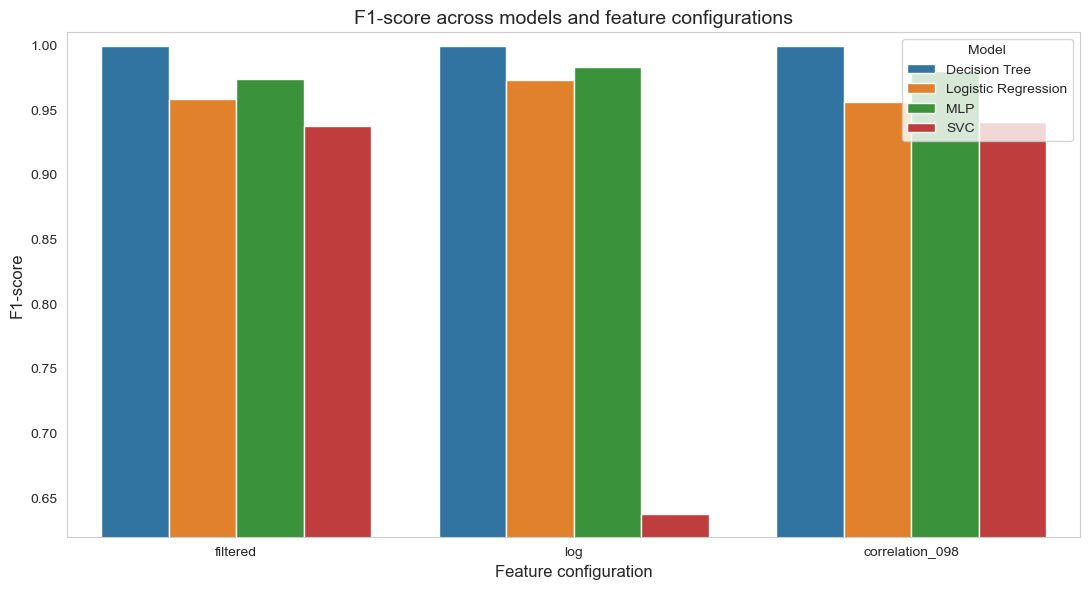

In [6]:
def plot_f1_results(results):
    plt.figure(figsize=(11, 6))
    sns.barplot(
        data=results,
        x="Feature Set",
        y="F1",
        hue="Model",
    )
    plt.xlabel("Feature configuration")
    plt.ylabel("F1-score")
    plt.title("F1-score across models and feature configurations")
    plt.ylim(0.62, 1.01)
    plt.legend(title="Model")
    plt.grid(False)
    plt.show()

plot_f1_results(df)

In [7]:
ranking = (
    df[
        [
            "Model",
            "Feature Set",
            "Features Count",
            "F1",
            "FP Rate"
        ]
    ]
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(ranking)

,Model,Feature Set,Features Count,F1,FP Rate
0,Decision Tree,log,59,0.999246,0.000820
1,Decision Tree,filtered,59,0.999202,0.000922
2,Decision Tree,correlation_098,43,0.999158,0.001025
3,MLP,log,59,0.982955,0.030738
4,MLP,correlation_098,43,0.979774,0.044775
5,MLP,filtered,59,0.973609,0.059016
6,Logistic Regression,log,59,0.973383,0.060041
7,Logistic Regression,filtered,59,0.958696,0.083094
8,Logistic Regression,correlation_098,43,0.956210,0.078791
9,SVC,correlation_098,43,0.940954,0.080635


**Analysis**: tree-based models achieve the best overall performance. On the Decision Tree model the number of classification errors remains very low. In contrast, Logistic Regression, SVC and MLP achieve lower performance. Logistic Regression obtains its best result with the logarithmic feature set, reaching competitive F1 score of 0.97. MLP reaches its best result with the same configuration, obtaining a F1 score of 0.98. 

**Conclusion**: models capable of represent non-linear relationships are better suited to this problem. Tree-based models are effective when the complete dataset is available.

---

## The Effect of Log Transformation
**Objective**: evaluate whether logarithmic transformation improves the representation of highly skewed traffic features and consequently affects model performance.

---

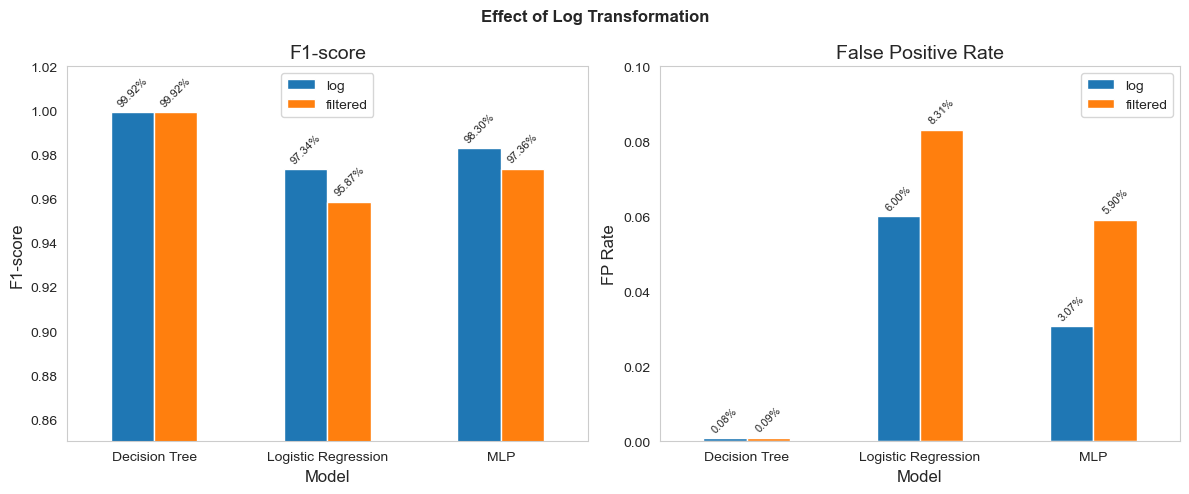

In [8]:
models_to_show = ["MLP", "Logistic Regression", "Decision Tree"]

df_plot = df[df["Model"].isin(models_to_show)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

numeric_f1 = (
    df_plot[df_plot["Feature Set"] == "log"]
    .set_index("Model")["F1"]
)

encoded_f1 = (
    df_plot[df_plot["Feature Set"] == "filtered"]
    .set_index("Model")["F1"]
)

f1_data = pd.DataFrame({
    "log": numeric_f1,
    "filtered": encoded_f1
})

ax = f1_data.plot(kind="bar", ax=axes[0])

axes[0].set_title("F1-score")
axes[0].set_ylabel("F1-score")
axes[0].set_ylim(0.85, 1.02)
axes[0].tick_params(axis="x", rotation=0)

for container in ax.containers:
    labels = [
        f"{bar.get_height() * 100:.2f}%"
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=45,
        fontsize=8
    )


# False Positive Rate
numeric_fp = (
    df_plot[df_plot["Feature Set"] == "log"]
    .set_index("Model")["FP Rate"]
)

encoded_fp = (
    df_plot[df_plot["Feature Set"] == "filtered"]
    .set_index("Model")["FP Rate"]
)

fp_data = pd.DataFrame({
    "log": numeric_fp,
    "filtered": encoded_fp
})

ax = fp_data.plot(kind="bar", ax=axes[1])

axes[1].set_title("False Positive Rate")
axes[1].set_ylabel("FP Rate")
axes[1].set_ylim(0, 0.1)
axes[1].tick_params(axis="x", rotation=0)

for container in ax.containers:
    labels = [
        f"{bar.get_height() * 100:.2f}%"
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        rotation=45,
        fontsize=8
    )


plt.suptitle("Effect of Log Transformation", fontweight="bold")
plt.show()

**Analysis**: for the logistic regression the improvement from `filtered` to `log` is significant. F1-score increases by approximately 1.47 percentage points, while FP-rate decreases from 8.31% to 6.00%. The number of false negatives also decreases from 116 to 12. The MLP model also benefits from this transformation. The F1-score increases by almost one percentage point and false positive rate is nearly reduced by half. The logarithmic transformation has very limited effect on tree-based models.

**Conclusion**: logarithmic transformation makes the classes easier to separate for a linear model, possibly by reducing the influence of extreme values and improving the distribution of highly skewed traffic variables. It provides little additional value when tree-based models are used.

---

## Tree-based Models
**Objective**: improve the interpretability of Decision Tree models by identifying the features that contribute most to their classification decisions.

---

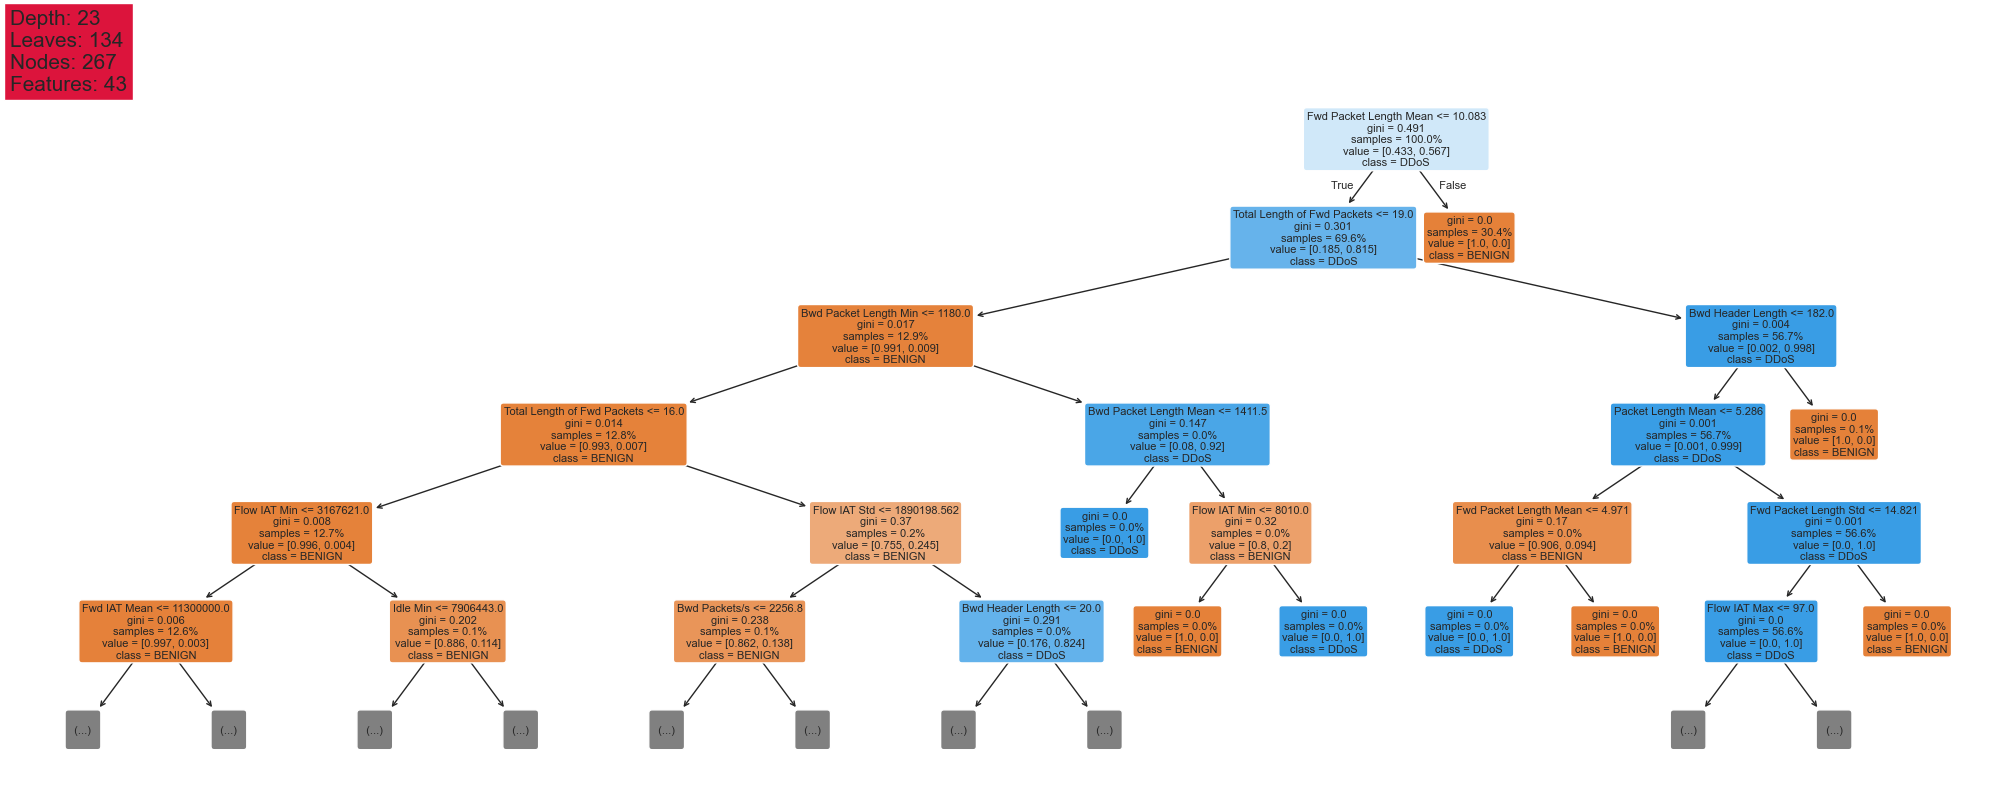

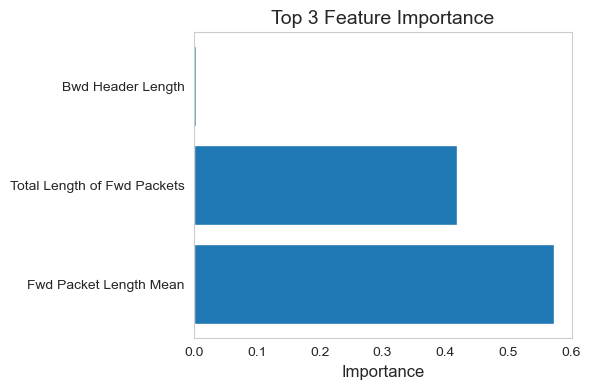

In [9]:
from sklearn.tree import plot_tree
import numpy as np
import joblib

def interpret_tree_based_models(model, feature_names, class_names=("BENIGN", "DDoS"), max_depth=3, figsize_tree=(20, 8), figsize_importance=(6, 4)):

    tree = model
    fig, ax = plt.subplots(figsize=figsize_tree)
    plot_tree(
        tree,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,    
        rounded=True,
        proportion=True,
        max_depth=max_depth,
        fontsize=8,
        ax=ax
    )
    stats_text = (
        f"Depth: {tree.get_depth()}\n"
        f"Leaves: {tree.get_n_leaves()}\n"
        f"Nodes: {tree.tree_.node_count}\n"
        f"Features: {len(feature_names)}"
    )
    ax.text(
        0.0,
        1.0,
        stats_text,
        fontsize=15,
        bbox=dict(facecolor="crimson",)
    )
    plt.show()

    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False).head(3)

    plt.figure(figsize=figsize_importance)

    plt.barh(
        importance["Feature"],
        importance["Importance"]
    )

    plt.xlabel("Importance")
    plt.title(f"Top 3 Feature Importance")
    plt.show()


model = joblib.load("models/stage2/unscaled/Decision Tree/correlation_098.pkl")
feature_names = df.loc[
    (df["Model"] == "Decision Tree") &
    (df["Feature Set"] == "correlation_098"),
    "Features Names"
].iloc[0]


interpret_tree_based_models(
    model,
    np.array(feature_names),
    max_depth=5
)


The feature-importance shows that the Decision Tree relies primarily on two features: `Fwd Packet Length Mean` and `Total Length of Fwd Packets`. This indicates that they are the dominant variables for separating BENIGN and DDoS traffic in this dataset but this does not mean that the model would achieve the same performance using only these two features. As the depth is 23, the tree still uses additional features in later branches that may be responsible for ambiguous cases that reduce FP and FN.  

## Computational costs
**Objective**: evaluate computational impact of feature reduction and determine whether reducing the dimensionality provides general benefits.

---

In [10]:
def feature_reduction_effect_table(df):
    metrics = ["F1", "FP Rate", "Train Time"]

    comparison = df[
        df["Feature Set"].isin(["filtered", "correlation_098"])
    ].copy()

    results = []

    for model in comparison["Model"].unique():
        model_data = comparison[
            comparison["Model"] == model
        ].set_index("Feature Set")

        filtered_features = model_data.loc[
            "filtered", "Features Count"
        ]

        reduced_features = model_data.loc[
            "correlation_098", "Features Count"
        ]

        row = {
            "Model": model,
            "Features": (
                f"{int(filtered_features)} → "
                f"{int(reduced_features)}"
            )
        }

        for metric in metrics:
            original = model_data.loc["filtered", metric]
            reduced = model_data.loc["correlation_098", metric]

            absolute_change = reduced - original
            relative_change = (
                absolute_change / original * 100
            )

            if metric in ["F1", "FP Rate"]:
                row[f"Δ {metric}"] = absolute_change * 100
                row[f"% change {metric}"] = relative_change
            else:
                row[f"Δ {metric}"] = absolute_change
                row[f"% change {metric}"] = relative_change

        results.append(row)

    return pd.DataFrame(results)


effect_table = feature_reduction_effect_table(df)

display(
    effect_table.style
    .format({
        "Δ F1": "{:+.3f} pp",
        "% change F1": "{:+.2f}%",
        "Δ FP Rate": "{:+.3f} pp",
        "% change FP Rate": "{:+.2f}%",
        "Δ Train Time": "{:+.3f} s",
        "% change Train Time": "{:+.2f}%"
    })
)

,Model,Features,Δ F1,% change F1,Δ FP Rate,% change FP Rate,Δ Train Time,% change Train Time
0,Decision Tree,59 → 43,-0.004 pp,-0.00%,+0.010 pp,+11.11%,-0.601 s,-21.87%
1,Logistic Regression,59 → 43,-0.249 pp,-0.26%,-0.430 pp,-5.18%,-1.129 s,-5.29%
2,MLP,59 → 43,+0.616 pp,+0.63%,-1.424 pp,-24.13%,+2.203 s,+5.77%
3,SVC,59 → 43,+0.366 pp,+0.39%,-0.635 pp,-7.30%,-1886.209 s,-39.42%


**Analysis**: the feature reduction removes 16 features, corresponding to approximate 27.1% decrease in dimensionality. 
- Tree-based models maintains an almost identical performance after feature reduction while achieving a considerable improvement in computational efficiency. This suggests that many of the removed features were not necessary for the tree to perform its main decision splits.
- Logistic Regression: the reduction decreases the FP rate and computational cost. However, it has a negative effect on the F1 score, reducing the model’s overall performance. Feature reduction is not beneficial overall, since the improvement in the FP Rate does not compensate for the loss in detection capability.
- MLP: clearly improves F1-score and FP Rate after feature reduction. This improvement may indicate that removing redundant features facilitates the learning process and reduces interference between variables. The increase in training time is unexpected, since reducing the number of features would normally be expected to decrease the computational cost. This behaviour may be related to the variability of the optimisation process, the number of iterations required for convergence or the specific training configuration.

**Conclusion**: feature reduction does not lead to a general improvement in model performance, except from MLP. Its main benefit is the reduction on computational efficiency over tree-based models. 



---

## The Effect of Feature Scaling

**Objective**: evaluate the effect of feature standardization on a scale-sensitive model using the reduced feature representation

---

In [11]:
RESULTS = "results/results_stage_II_scaled.json"
df_scaled = pd.read_json(RESULTS, orient="split")
display(df_scaled)

,Model,Feature Set,Features Count,Train Time,Train Accuracy,Train F1,BENIGN,DDoS,FP,FN,TP,TN,FP Rate,Accuracy,F1,Features Names
0,Logistic Regression,correlation_098_scaled,43,3.774,0.998168,0.998168,9760,12801,24,16,12785,9736,0.002459,0.998227,0.998227,"[Flow Duration, Total Fwd Packets, Total Backw..."
1,SVC,correlation_098_scaled,43,40.753,0.998754,0.998754,9760,12801,17,15,12786,9743,0.001742,0.998582,0.998582,"[Flow Duration, Total Fwd Packets, Total Backw..."
2,MLP,correlation_098_scaled,43,25.339,0.999325,0.999325,9760,12801,7,13,12788,9753,0.000717,0.999114,0.999114,"[Flow Duration, Total Fwd Packets, Total Backw..."


Standardization provides excellent classification performance on the 43-feature correlation_098 representation. Both Logistic Regression, MLP and SVC achieve F1-scores above 0.99 on the test set. The MLP achieves particularly strong results, with only 7 false positives and 13 false negatives, while Logistic Regression is the worse producing 24 false positives and 16 false negatives. In addition, the computational cost of the SVC has been reduced drastically. These results show that the standardized representation is highly **effective** for both scale-sensitive models. Its computational cost and overall balance with the other configurations are considered in the subsequent performance–efficiency trade-off analysis.

## Performance-Efficiency Trade-off
**Objective**: identify the most balanced configuration.

---

In [12]:
import numpy as np
from src.utils import intro

def overall_model_selection(
    df,
    f1_weight=0.50,
    fp_rate_weight=0.2,
    features_weight=0.10,
    train_time_weight=0.10,
    interpretability_weight=0.10
):

    results = df.copy()
    
    # Higher = easier to interpret
    interpretability_scores = {
        "Logistic Regression": 1.00,
        "Decision Tree": 1.00,
        "Random Forest": 0.75,
        "MLP": 0.50,
        "SVC": 0.50
    }

    results["Interpretability"] = (
        results["Model"]
        .map(interpretability_scores)
    )
    
    
    # F1: higher is better
    f1_min = results["F1"].min()
    f1_max = results["F1"].max()

    if f1_max != f1_min:
        results["F1 Score"] = (
            (results["F1"] - f1_min) /
            (f1_max - f1_min)
        )
    else:
        results["F1 Score"] = 1.0

    # FP Rate: lower is better
    fp_min = results["FP Rate"].min()
    fp_max = results["FP Rate"].max()

    if fp_max != fp_min:
        results["FP Rate Score"] = (
            (fp_max - results["FP Rate"]) /
            (fp_max - fp_min)
        )
    else:
        results["FP Rate Score"] = 1.0
    
    
    # Number of features: lower is better
    features_min = results["Features Count"].min()
    features_max = results["Features Count"].max()

    if features_max != features_min:
        results["Dimensionality Score"] = (
            (features_max - results["Features Count"]) /
            (features_max - features_min)
        )
    else:
        results["Dimensionality Score"] = 1.0

    # Training time: lower is better
    time_min = results["Train Time"].min()
    time_max = results["Train Time"].max()

    if time_max != time_min:
        results["Efficiency Score"] = (
            (time_max - results["Train Time"]) /
            (time_max - time_min)
        )
    else:
        results["Efficiency Score"] = 1.0
    
    
    total_weight = (
        f1_weight +
        fp_rate_weight +
        features_weight +
        train_time_weight +
        interpretability_weight
    )

    if not np.isclose(total_weight, 1.0):
        raise ValueError(
            f"Weights must sum to 1.0. Current sum: {total_weight:.2f}"
        )

    results["Overall Score"] = (
        results["F1 Score"] * f1_weight +
        results["FP Rate Score"] * fp_rate_weight +
        results["Dimensionality Score"] * features_weight +
        results["Efficiency Score"] * train_time_weight +
        results["Interpretability"] * interpretability_weight
    )
    
    
    results = results.sort_values(
        "Overall Score",
        ascending=False
    ).reset_index(drop=True)

    results["Rank"] = np.arange(1, len(results) + 1)
    
    
    display_columns = [
        "Rank",
        "Model",
        "Feature Set",
        "Features Count",
        "F1",
        "FP Rate",
        "Train Time",
        "Interpretability",
        "F1 Score",
        "FP Rate Score",
        "Dimensionality Score",
        "Efficiency Score",
        "Overall Score"
    ]

    display(
        results[display_columns].round(4)
    )
    
    
    best = results.iloc[0]

    intro("BEST BALANCED CONFIGURATION")

    print(f"Model:             {best['Model']}")
    print(f"Feature Set:       {best['Feature Set']}")
    print(f"Features:          {best['Features Count']}")
    print(f"F1:                {best['F1']:.6f}")
    print(f"FP Rate:           {best['FP Rate']:.6f}")
    print(f"Training Time:     {best['Train Time']:.3f} s")
    print(f"Interpretability:  {best['Interpretability']:.2f}")
    print(f"Overall Score:     {best['Overall Score']:.4f}")

    return results

In [13]:
df["Scaling"] = "No Scaling"
df_scaled["Scaling"] = "StandardScaler"

df_all = pd.concat(
    [df, df_scaled],
    ignore_index=True
)
selection_results = overall_model_selection(df_all)

,Rank,Model,Feature Set,Features Count,F1,FP Rate,Train Time,Interpretability,F1 Score,FP Rate Score,Dimensionality Score,Efficiency Score,Overall Score
0,1,Decision Tree,correlation_098,43,0.9992,0.0010,2.147,1.0,0.9998,0.9996,1.0,1.0000,0.9998
1,2,Logistic Regression,correlation_098_scaled,43,0.9982,0.0025,3.774,1.0,0.9972,0.9975,1.0,0.9997,0.9981
2,3,MLP,correlation_098_scaled,43,0.9991,0.0007,25.339,0.5,0.9996,1.0000,1.0,0.9952,0.9493
3,4,SVC,correlation_098_scaled,43,0.9986,0.0017,40.753,0.5,0.9982,0.9986,1.0,0.9919,0.9480
4,5,Logistic Regression,correlation_098,43,0.9562,0.0788,20.229,1.0,0.8808,0.8900,1.0,0.9962,0.9180
5,6,MLP,correlation_098,43,0.9798,0.0448,40.355,0.5,0.9461,0.9379,1.0,0.9920,0.9098
6,7,Decision Tree,log,59,0.9992,0.0008,2.714,1.0,1.0000,0.9999,0.0,0.9999,0.9000
7,8,Decision Tree,filtered,59,0.9992,0.0009,2.748,1.0,0.9999,0.9997,0.0,0.9999,0.8999
8,9,Logistic Regression,log,59,0.9734,0.0600,20.611,1.0,0.9284,0.9164,0.0,0.9961,0.8471
9,10,Logistic Regression,filtered,59,0.9587,0.0831,21.358,1.0,0.8877,0.8839,0.0,0.9960,0.8202


BEST BALANCED CONFIGURATION
Model:             Decision Tree
Feature Set:       correlation_098
Features:          43
F1:                0.999158
FP Rate:           0.001025
Training Time:     2.147 s
Interpretability:  1.00
Overall Score:     0.9998


## Final Conclusions
- The overall comparison shows that tree-based models provide the best balance between detection performance, dimensionality, computation cost and interpretability. 
- The **Decision Tree correlation_098** achieves the highest overall score, using only 43 features and a very low FP rate of 0.10%. Also, has the lowest training time among the evaluated configurations and offers a directly interpretable decision structure. 
- The Ranomd Forest has a higher computational cost and lower direct interpretability. This indicates that the additional complexity of ensemble does not provide a meaningful improvement in detection performance for this dataset.